In [14]:
import sys
from pathlib import Path

# adds parent file of the current directory
# to the paths in which Python looks for modules to import
# in the current Python process
sys.path.append(str(Path.cwd().parent))

from src.config import DATA, BDIFF_RAW_DIR, BDIFF_CLEAN_DIR, GEO_DATA_CLEAN_DIR, ROOT_DIR, FIGURES_DIR
from utils.cleaning_utils import delete, normalize_columns_names, normalize_text_columns_cells, optimize_numeric_column, fill_rate
from utils.analysis_utils import plot_missing_bar, plot_numeric_histograms, plot_corr_heatmap, plot_qualitative

import numpy as np
import pandas as pd

import lightgbm as lgb
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix

import xgboost as xgb

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Chargement instantané des 2,3 millions de lignes
df_dataset = pd.read_parquet(DATA /'df_dataset.parquet')

print(f"Dataset chargé avec succès : {df_dataset.shape}")
# vérifie que la taille et les types sont déjà optimisés
print(df_dataset.info())

Dataset chargé avec succès : (2321280, 19)
<class 'pandas.DataFrame'>
RangeIndex: 2321280 entries, 0 to 2321279
Data columns (total 19 columns):
 #   Column                    Dtype   
---  ------                    -----   
 0   code_insee                category
 1   annee                     int16   
 2   mois                      int8    
 3   nb_incendies              int16   
 4   surface_brulee_ha         float32 
 5   target_occurrence         int8    
 6   target_log_surface        float32 
 7   sin_mois                  float32 
 8   cos_mois                  float32 
 9   is_summer_peak            int8    
 10  is_spring_peak            int8    
 11  latitude                  float32 
 12  longitude                 float32 
 13  population                Int32   
 14  superficie_hectare        Int32   
 15  densite                   float32 
 16  altitude_moyenne          Int16   
 17  feux_commune_last_12m     float32 
 18  surface_commune_last_12m  float32 
dtypes: Int16(1

* **Variables exclues** : On retire les métadonnées temporelles/géographiques brutes (`code_insee`, `annee`, `mois`) ainsi que la variable cible et ses déclinaisons directes (`nb_incendies`, `surface_brulee_ha`, `target_log_surface`) pour éviter les fuites d'information (*Data Leakage*)[1].
* **Variables conservées** : Toutes les caractéristiques géographiques, temporelles cycliques (`sin_mois`, `cos_mois`), contextuelles et historiques glissantes (`feux_commune_last_12m`)

In [6]:

#  DÉFINITION DES FEATURES (X) ET DE LA TARGET (y)

# Colonnes à exclure des variables explicatives X
cols_to_exclude = [
    'code_insee', 'annee', 'mois',
    'target_occurrence', 'nb_incendies', 'surface_brulee_ha',
    'target_log_surface'
]

X = [col for col in df_dataset.columns if col not in cols_to_exclude]
y = 'target_occurrence'

print(f"Nombre de features sélectionnées ({len(X)}) : {X}")


Nombre de features sélectionnées (12) : ['sin_mois', 'cos_mois', 'is_summer_peak', 'is_spring_peak', 'latitude', 'longitude', 'population', 'superficie_hectare', 'densite', 'altitude_moyenne', 'feux_commune_last_12m', 'surface_commune_last_12m']


### Structuration et Découpage Temporel


* **Train (2011–2021)** : 11 années complètes pour que le modèle apprenne les motifs réguliers de risque.

* **Validation (2022)** : L'année 2022 a été exceptionnelle en termes de sécheresse et de mégafeux en France ; c'est un excellent crash-test pour régler le seuil de décision et les hyperparamètres.

* **Test (2023–2025)** : Évaluation finale "hors du temps" (*out-of-time*) pour simuler les conditions réelles de prédiction future.

In [ ]:

# -----------------------------------------------------------------------------
# SPLIT TEMPOREL (TRAIN / VALIDATION / TEST)
# -----------------------------------------------------------------------------

# Masques temporels
mask_train = df_dataset['annee'] <= 2021
mask_val   = df_dataset['annee'] == 2022
mask_test  = df_dataset['annee'] >= 2023

# Création des sous-ensembles
X_train, y_train = df_dataset.loc[mask_train, X], df_dataset.loc[mask_train, y]
X_val,   y_val   = df_dataset.loc[mask_val, X],   df_dataset.loc[mask_val, y]
X_test,  y_test  = df_dataset.loc[mask_test, X],  df_dataset.loc[mask_test, y]

print("Split temporel effectué avec succès !")


Split temporel effectué avec succès !


In [8]:
#  Contrôle des volumes et du taux de feux par jeu de données

def print_split_stats(name, X_sub, y_sub):
    total = len(y_sub)
    positives = y_sub.sum()
    rate = (positives / total) * 100
    print(f"--- {name} ---")
    print(f"  Lignes    : {total:,}".replace(",", " "))
    print(f"  Incendies : {positives:,} ({rate:.2f}%)".replace(",", " "))

print_split_stats("TRAIN (2011–2021)", X_train, y_train)
print_split_stats("VAL   (2022)",       X_val,   y_val)
print_split_stats("TEST  (2023–2025)",  X_test,  y_test)


--- TRAIN (2011–2021) ---
  Lignes    : 1 857 024
  Incendies : 32 870 (1.77%)
--- VAL   (2022) ---
  Lignes    : 116 064
  Incendies : 3 654 (3.15%)
--- TEST  (2023–2025) ---
  Lignes    : 348 192
  Incendies : 5 571 (1.60%)


**Calcul du poids de déséquilibre (** **scale\_pos\_weight** **)** :

In [ ]:
# Calcul du ratio entre mois sans feu (0) et mois avec feu (1) sur le jeu d'entraînement
ratio_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()

print(f"Poids attribué à la classe positive (scale_pos_weight) : {ratio_pos_weight:.2f}")


Poids attribué à la classe positive (scale_pos_weight) : 55.50


In [ ]:

# -----------------------------------------------------------------------------
# INSTANCIATION ET ENTRAÎNEMENT DU MODÈLE
# -----------------------------------------------------------------------------

model_lgb = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    scale_pos_weight=ratio_pos_weight,
    random_state=42,
    n_jobs=-1
)

# Entraînement avec arrêt précoce (early stopping) sur l'année de validation (2022)
model_lgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
)


/home/coule/Documents/projets/incendies/.venv/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 32870, number of negative: 1824154
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.045255 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1839
[LightGBM] [Info] Number of data points in the train set: 1857024, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.017700 -> initscore=-4.016311
[LightGBM] [Info] Start training from score -4.016311


,max_depth,6
,learning_rate,0.05
,n_estimators,300
,random_state,42
,n_jobs,-1
,scale_pos_weight,np.float64(55.49601460298144)
,boosting_type,'gbdt'
,num_leaves,31
,subsample_for_bin,200000
,objective,None
,class_weight,None


In [ ]:
# -----------------------------------------------------------------------------
# ÉVALUATION DES PERFORMANCES (ROC-AUC & PR-AUC)
# -----------------------------------------------------------------------------

# Probabilités prédites pour la classe 1 (présence d'incendie)
y_val_pred_proba = model_lgb.predict_proba(X_val)[:, 1]
y_test_pred_proba = model_lgb.predict_proba(X_test)[:, 1]

# Calcul des scores
roc_val  = roc_auc_score(y_val, y_val_pred_proba)
pr_val   = average_precision_score(y_val, y_val_pred_proba)

roc_test = roc_auc_score(y_test, y_test_pred_proba)
pr_test  = average_precision_score(y_test, y_test_pred_proba)

print("=== PERFORMANCES DU MODÈLE LIGHTGBM BASELINE ===")
print(f"Validation (2022)      | ROC-AUC : {roc_val:.4f} | PR-AUC (Average Precision) : {pr_val:.4f}")
print(f"Test       (2023–2025) | ROC-AUC : {roc_test:.4f} | PR-AUC (Average Precision) : {pr_test:.4f}")


n=== PERFORMANCES DU MODÈLE LIGHTGBM BASELINE ===
Validation (2022)      | ROC-AUC : 0.6849 | PR-AUC (Average Precision) : 0.0938
Test       (2023–2025) | ROC-AUC : 0.7564 | PR-AUC (Average Precision) : 0.0715


**PR-AUC (Precision-Recall AUC)** :
* La fréquence naturelle des feux dans le dataset n'est que de **1,81 %** (0,0181). C'est le score d'un modèle aléatoire.
* Avec **0,0938 (9,38 % en 2022)** et **0,0715 (7,15 % sur 2023–2025)**, le modèle s'en sort **4 à 5 fois mieux que le hasard pur**. Il capte donc déjà un réel signal de risque !


**ROC-AUC** :
* **0,7564 sur le jeu de Test (2023–2025)** : Le modèle réussit bien à ordonner les communes selon leur niveau de risque global.
* Le score en 2022 (0,6849) est légèrement inférieur, ce qui s'explique par le fait que 2022 a été une année climatique extrême et atypique (sécheresse et mégafeux historiques).

/tmp/ipykernel_2760/1511614936.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


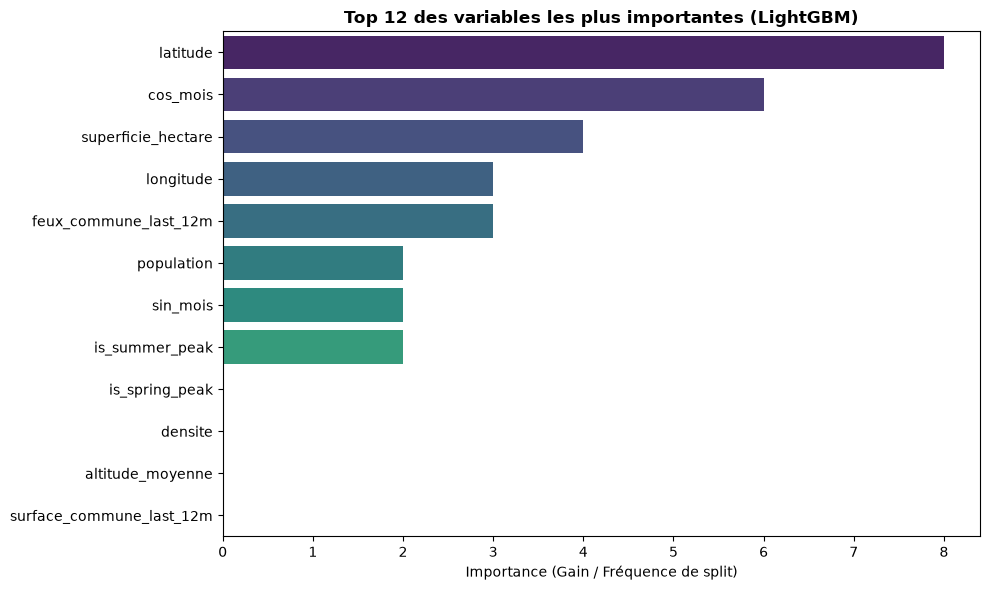

In [20]:

# -----------------------------------------------------------------------------
# 4. IMPORTANCE DES FEATURES (LightGBM)
# -----------------------------------------------------------------------------

df_importance = pd.DataFrame({
    'Feature': X,
    'Importance': model_lgb.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_importance.head(12),
    x='Importance',
    y='Feature',
    palette='viridis'
)
plt.title("Top 12 des variables les plus importantes (LightGBM)", fontsize=12, fontweight='bold')
plt.xlabel("Importance (Gain / Fréquence de split)")
plt.ylabel("")
plt.tight_layout()

###  XGBOOST

In [ ]:
# -----------------------------------------------------------------------------
# 1. INSTANCIATION ET ENTRAÎNEMENT XGBOOST
# -----------------------------------------------------------------------------

model_xgb = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=ratio_pos_weight,
    tree_method='hist',
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=30
)

# Entraînement avec évaluation sur l'année de validation (2022)
model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print(" Entraînement de XGBoost terminé !")


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",30
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [28]:
# -----------------------------------------------------------------------------
# 2. PRÉDICTIONS ET CALCUL DES SCORES
# -----------------------------------------------------------------------------

y_val_pred_xgb = model_xgb.predict_proba(X_val)[:, 1]
y_test_pred_xgb = model_xgb.predict_proba(X_test)[:, 1]

roc_val_xgb  = roc_auc_score(y_val, y_val_pred_xgb)
pr_val_xgb   = average_precision_score(y_val, y_val_pred_xgb)

roc_test_xgb = roc_auc_score(y_test, y_test_pred_xgb)
pr_test_xgb  = average_precision_score(y_test, y_test_pred_xgb)

print("=== PERFORMANCES DU MODÈLE XGBOOST BASELINE ===")
print(f"Validation (2022)      | ROC-AUC : {roc_val_xgb:.4f} | PR-AUC (Average Precision) : {pr_val_xgb:.4f}")
print(f"Test       (2023–2025) | ROC-AUC : {roc_test_xgb:.4f} | PR-AUC (Average Precision) : {pr_test_xgb:.4f}")

=== PERFORMANCES DU MODÈLE XGBOOST BASELINE ===
Validation (2022)      | ROC-AUC : 0.7122 | PR-AUC (Average Precision) : 0.1297
Test       (2023–2025) | ROC-AUC : 0.7921 | PR-AUC (Average Precision) : 0.1283


In [26]:
# TABLEAU COMPARATIF DES PERFORMANCES

df_comparaison = pd.DataFrame({
    'Modèle': ['LightGBM', 'XGBoost'],
    'ROC-AUC (Val 2022)': [roc_val, roc_val_xgb],
    'PR-AUC (Val 2022)': [pr_val, pr_val_xgb],
    'ROC-AUC (Test 2023–2025)': [roc_test, roc_test_xgb],
    'PR-AUC (Test 2023–2025)': [pr_test, pr_test_xgb]
})

print("=== TABLEAU COMPARATIF DES MODÈLES BASELINE ===")
print(df_comparaison.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


=== TABLEAU COMPARATIF DES MODÈLES BASELINE ===
  Modèle  ROC-AUC (Val 2022)  PR-AUC (Val 2022)  ROC-AUC (Test 2023–2025)  PR-AUC (Test 2023–2025)
LightGBM              0.6849             0.0938                    0.7564                   0.0715
 XGBoost              0.7122             0.1297                    0.7921                   0.1283


/tmp/ipykernel_2760/3337874832.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


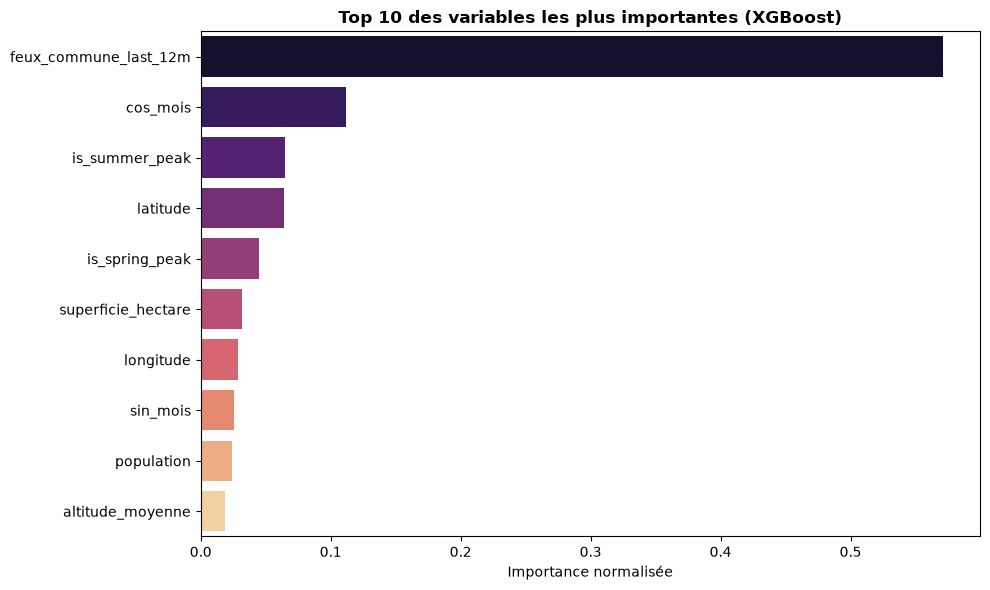

In [27]:
#  COMPARAISON GRAPHIQUE DES IMPORTANCES DE FEATURES

df_imp_xgb = pd.DataFrame({
    'Feature': X,
    'Importance_XGB': model_xgb.feature_importances_
}).sort_values(by='Importance_XGB', ascending=False)

df_imp_lgb = pd.DataFrame({
    'Feature': X,
    'Importance_LGB': model_lgb.feature_importances_ / model_lgb.feature_importances_.sum()
})

df_imp_merge = pd.merge(df_imp_xgb, df_imp_lgb, on='Feature')

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_imp_merge.head(10),
    x='Importance_XGB',
    y='Feature',
    palette='magma'
)
plt.title("Top 10 des variables les plus importantes (XGBoost)", fontsize=12, fontweight='bold')
plt.xlabel("Importance normalisée")
plt.ylabel("")
plt.tight_layout()

**PR-AUC (Test 2023–2025)** :
* **XGBoost obtient 0.1283 (12,83 %)** contre **0.0715 (7,15 %)** pour LightGBM.
* C'est presque le **double de performance** par rapport à LightGBM, et plus de **7 fois mieux** qu'un choix aléatoire (1,81 %).
* **Stabilité remarquable** : XGBoost conserve la même précision moyenne en Validation (12,97 %) et en Test (12,83 %), ce qui prouve qu'il ne fait pas de surapprentissage (*overfitting*).


**ROC-AUC (Test 2023–2025)** :
* **0.7921 pour XGBoost** (contre 0.7564 pour LightGBM), frôlant la barre très solide des **0.80**.